# Archetype 4 — Base + Heat Pump (HP + Thermal Storage)

## Purpose

Computes the annual TCoE for **Archetype 4: Base + Heat Pump with thermal heat storage** across 3 strategies x 7 DSOs -> **21 runs**.

The HP can shift its electricity draw over time while the heat storage (HS) decouples heat production from heat demand. This makes the HP the prototypical **§14a-eligible flexible load**: operators must grant DSOs the right to temporarily curtail the HP in exchange for reduced DSO charges.

| Strategy | Flexible resource | Signal |
|---|---|---|
| **no_flex** | None — HP follows the fixed HZ2 profile | none |
| **dt_flex** | LP shifts HP electricity over the year | spot (ct/kWh) on total site import |
| **tcoe_flex** | LP per DSO x §14a option — shifts HP electricity | spot + DSO HP-rate + levies (ct/kWh) |

**§14a module optimisation:** For `tcoe_flex`, the LP is solved under each of the three §14a options (opt1 / opt2 / opt1+3); the option yielding the lowest billed annual cost is retained.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 base demand (kWh/slot) |
| `hp_kassel_hz2_2026_15min.csv` | HP electrical demand profile, Kassel 2026 (kWh/slot) |
| `hp_hz2_parameters_kassel_2026.csv` | COP, HS capacity, q_loss — frozen optimisation parameters |
| `spot_prices_de_lu_2025_15min.csv` | Day-ahead spot price (ct/kWh) |
| `dso_tariffs_residential_2026.csv` | Residential base tariffs + §14a module parameters |
| `dso_mod3_timebands_2026.csv` | §14a Modul 3 HT/NT/ST timeband rules per DSO |
| `residential_taxes_2026.csv` | German levies (ct/kWh, pre-VAT) |

## Output (`outputs/`)

`results_base_hp_2026.csv` — 21 rows x cost-component columns including `billing_14a_option` and `optimized_14a_option`.

## Billing convention

Pre-VAT levy bundle in net subtotal; single 19% VAT on full subtotal. `cost_smart_operating_net_eur = 100 EUR/year`. §14a Modul 1 rebate (annual EUR) enters the DSO volumetric component for opt1 and opt1+3.

## Solver

Gurobi via PuLP. LP (continuous, no binary variables) at 15-min resolution (T = 35,040). One LP per strategy x DSO x §14a option for `tcoe_flex` (max 7 x 3 = 21 LP solves).

## Thesis reference

Chapter 5, Section 5.1 — Results: Archetype 4 (Base + HP)


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f'Repo root (containing {marker}) not found.')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')


Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and HP parameters

In [7]:
# Base demand (H25)
base_demand = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv',
                          parse_dates=['timestamp'])

# HP electrical demand profile (HZ2, Kassel 2026)
# Note: this CSV uses 'datetime' as index column — rename for consistency
hp_profile = pd.read_csv(INPUTS / 'hp_kassel_hz2_2026_15min.csv',
                         parse_dates=['datetime'])
hp_profile = hp_profile.rename(columns={'datetime': 'timestamp'})

# Spot prices
spot = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv',
                   parse_dates=['timestamp'])

df = (base_demand
      .merge(hp_profile[['timestamp', 'energy_kWh']], on='timestamp')
      .merge(spot[['timestamp', 'price_ct_kWh']], on='timestamp'))
df['price_ct_kWh'] = df['price_ct_kWh'].ffill().bfill()
n = len(df)

# ── HP physical parameters (frozen at export time in input notebook 05) ────────
hp_params   = pd.read_csv(INPUTS / 'hp_hz2_parameters_kassel_2026.csv',
                           index_col='parameter')['value']
COP         = float(hp_params['opt_COP_constant'])       # [-] constant COP (Stute Eq.18, mean T_amb)
q_loss_HS   = float(hp_params['opt_q_losses_HS_per_h'])  # [1/h] HS standby loss rate
P_HP_max_el = float(hp_params['opt_Q_HP_max_el_kW'])     # [kW_el] HP max electric power
Q_HP_max_th = P_HP_max_el * COP                           # [kW_th] HP max thermal output
E_HS_max    = float(hp_params['opt_HS_capacity_hours']) * Q_HP_max_th  # [kWh_th] 2h * Q_HP_max_th

hp_p = {'COP': COP, 'q_loss_HS': q_loss_HS, 'Q_HP_max_th': Q_HP_max_th, 'E_HS_max': E_HS_max}

# ── Levies and tariffs ──────────────────────────────────────────────────────────
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region'] == 'DE', 'Total_no_VAT_ct_kWh'].iloc[0])
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
SMART_OP_EUR = 100.0   # annual flat smart-meter / operating cost (net EUR)
VAT_RATE     = 0.19

# ── Core arrays ──────────────────────────────────────────────────────────────────
q_base       = df['demand_kwh'].values    # [kWh_el/slot] base electricity demand
spot_arr     = df['price_ct_kWh'].values  # [ct/kWh]
E_hp_profile = df['energy_kWh'].values    # [kWh_el/slot] HP electrical demand (no-flex profile)

# Thermal heat demand: Q_th[t] = COP * E_hp_el[t]
# The profile was generated assuming a fixed COP; multiplying recovers the thermal demand
# that the LP must satisfy every slot via HP direct + storage discharge.
Q_heat_kWh   = E_hp_profile * COP        # [kWh_th/slot]

E_grid_nf    = q_base + E_hp_profile     # no-flex total grid import

print(f'T = {n} slots  |  base: {q_base.sum():.1f} kWh/yr  |  HP (no-flex): {E_hp_profile.sum():.1f} kWh/yr')
print(f'HP params : COP={COP}, Q_HP_max_th={Q_HP_max_th:.1f} kW_th, E_HS_max={E_HS_max:.1f} kWh_th, q_loss={q_loss_HS}/h')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh  |  Smart op.: {SMART_OP_EUR} EUR/year')


T = 35040 slots  |  base: 4500.0 kWh/yr  |  HP (no-flex): 4500.0 kWh/yr
HP params : COP=3.2, Q_HP_max_th=20.0 kW_th, E_HS_max=40.0 kWh_th, q_loss=0.002/h
Levies (pre-VAT): 6.64 ct/kWh  |  Smart op.: 100.0 EUR/year


## Step 2 — §14a Modul 3 schedule

**What is §14a EnWG?**
§14a of the German Energy Industry Act entitles residential operators of *controllable loads* (heat pumps, EVs, battery storage) to a reduced network charge in exchange for granting the DSO the right to temporarily curtail the device. Three structurally different billing modules exist:

| Module | Mechanism | HP billing |
|---|---|---|
| **Modul 1** | HP billed at standard DSO rate + fixed annual rebate (EUR/year) | base rate + rebate |
| **Modul 2** | HP billed at a permanently reduced flat rate (ct/kWh) | reduced flat rate |
| **Modul 3** | HP billed at time-differentiated HT/NT/ST rate | timeband rate |

**Why Modul 3 creates the strongest scheduling incentive:**
Modul 3 introduces a high-tariff (HT) window — typically 4–5 h/day in the peak evening period — and a very low night-tariff (NT) window, with the base rate as shoulder tariff (ST). Shifting HP operation from HT into NT can save 10–15 ct/kWh on the DSO component alone. The `tcoe_flex` LP explicitly optimises HP scheduling under each module option per DSO and retains the cheapest outcome.

Timeband rules are data-driven from `dso_mod3_timebands_2026.csv`.


In [8]:
MOD3_TIMEBANDS = pd.read_csv(INPUTS / 'dso_mod3_timebands_2026.csv')

def build_hp_dso_rate_mod3(ts_index, dso_name: str, dso_row) -> np.ndarray:
    """Return per-slot §14a Modul 3 DSO rate [ct/kWh] for the HP meter.

    Applies HT/NT/ST bands from the timebands CSV; unassigned slots default to ST (base rate).
    """
    ht = float(dso_row['HT_ct_kWh'])
    nt = float(dso_row['NT_ct_kWh'])
    st = float(dso_row['ST_ct_kWh'])

    T   = len(ts_index)
    idx = pd.to_datetime(ts_index)

    hours  = idx.dt.hour + idx.dt.minute / 60.0
    months = idx.dt.month
    is_q1q4 = (months <= 3) | (months >= 10)
    is_q2q3 = (months >= 4) & (months <= 9)

    rates = np.full(T, st, dtype=float)   # default: ST

    def in_range(h, start, end):
        if start <= end:
            return (h >= start) & (h < end)
        return (h >= start) | (h < end)   # handles midnight-wrapping windows

    tb = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso_name]
    # Apply NT first so HT overwrites any overlaps
    for band, level in [('NT', nt), ('HT', ht)]:
        for _, r in tb[tb['band'] == band].iterrows():
            qg = str(r['quarter_group'])
            if   qg == 'all':   qmask = np.ones(T, dtype=bool)
            elif qg == 'q1q4':  qmask = is_q1q4
            elif qg == 'q2q3':  qmask = is_q2q3
            else:               qmask = np.ones(T, dtype=bool)
            rates[qmask & in_range(hours, float(r['start_hour']), float(r['end_hour']))] = level

    return rates

# ── Compact schedule overview (all 7 DSOs x 4 quarters) ───────────────────────
def _fmt_h(h):
    m = int(round(float(h) * 60)) % 1440
    return f'{m // 60:02d}:{m % 60:02d}'

rows = []
for _, dso_row in dso_tariffs.iterrows():
    dso = str(dso_row['DSO'])
    tb  = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso]
    for qlab, qg in [('Q1', 'q1q4'), ('Q2', 'q2q3'), ('Q3', 'q2q3'), ('Q4', 'q1q4')]:
        tbq  = tb[(tb['quarter_group'] == 'all') | (tb['quarter_group'] == qg)]
        def wins(band):
            w = tbq[tbq['band'] == band]
            return ', '.join(f"{_fmt_h(r['start_hour'])}-{_fmt_h(r['end_hour'])}" for _, r in w.iterrows()) or '-'
        rows.append({'DSO': dso, 'Q': qlab,
                     'HT (ct/kWh)': dso_row['HT_ct_kWh'], 'HT windows': wins('HT'),
                     'NT (ct/kWh)': dso_row['NT_ct_kWh'], 'NT windows': wins('NT'),
                     'ST (ct/kWh)': dso_row['ST_ct_kWh']})
display(pd.DataFrame(rows))


,DSO,Q,HT (ct/kWh),HT windows,NT (ct/kWh),NT windows,ST (ct/kWh)
0,Westnetz,Q1,15.65,15:00-20:00,0.95,00:00-07:00,9.53
1,Westnetz,Q2,15.65,15:00-20:00,0.95,00:00-07:00,9.53
2,Westnetz,Q3,15.65,15:00-20:00,0.95,00:00-07:00,9.53
3,Westnetz,Q4,15.65,15:00-20:00,0.95,00:00-07:00,9.53
4,Bayernwerk,Q1,9.03,-,0.47,-,4.72
5,Bayernwerk,Q2,9.03,17:00-22:00,0.47,10:00-15:00,4.72
6,Bayernwerk,Q3,9.03,17:00-22:00,0.47,10:00-15:00,4.72
7,Bayernwerk,Q4,9.03,-,0.47,-,4.72
8,E.DIS,Q1,8.80,"10:15-12:00, 16:45-20:15",0.55,"00:00-05:00, 23:30-00:00",5.47
9,E.DIS,Q2,8.80,-,0.55,-,5.47


## Step 3 — LP solver (`solve_base_hp`)

Continuous LP (Gurobi via PuLP). Decision variables per 15-min slot:

| Variable | Unit | Description |
|---|---|---|
| `Q_HP_bld[t]` | kW_th | HP thermal power delivered directly to building |
| `Q_HP_HS[t]` | kW_th | HP thermal power stored in HS (charging) |
| `Q_HS_bld[t]` | kW_th | HS discharge to building |
| `P_HP_el[t]` | kW_el | HP electrical power draw |
| `E_HS[t]` | kWh_th in [0, E_HS_max] | HS energy level at slot boundary |

Periodicity constraint `E_HS[0] = E_HS[T]` closes the year without assuming an arbitrary initial tank level.


In [9]:
def solve_base_hp(q_base, Q_heat_kWh, spot_ct, hp_params, strategy,
                   c_imp_hp=None, time_limit_s=300, debug=None):
    """Annual LP for Base + HP + thermal storage.

    Parameters
    ----------
    q_base       : [kWh_el/slot] exogenous base electricity demand
    Q_heat_kWh   : [kWh_th/slot] thermal heat demand (= E_hp_profile * COP)
    spot_ct      : [ct/kWh] day-ahead spot price
    strategy     : 'dt_flex' | 'tcoe_flex'
    c_imp_hp     : [ct/kWh] full HP import marginal signal (tcoe_flex only)
    debug        : if dict, filled with solution arrays for QA

    Returns (E_grid, E_hp_el) on success; (None, None) on infeasibility.
    """
    T    = len(q_base)
    dt_h = 0.25

    COP       = float(hp_params['COP'])
    q_loss    = float(hp_params['q_loss_HS'])
    Q_HP_max  = float(hp_params['Q_HP_max_th'])
    E_HS_max_ = float(hp_params['E_HS_max'])

    Q_heat_dot = Q_heat_kWh / dt_h   # [kWh_th/slot] -> [kW_th]

    prob = pulp.LpProblem('base_hp', pulp.LpMinimize)

    Q_HP_bld = [pulp.LpVariable(f'Q_HP_bld_{t}', lowBound=0) for t in range(T)]  # HP -> building
    Q_HP_HS  = [pulp.LpVariable(f'Q_HP_HS_{t}',  lowBound=0) for t in range(T)]  # HP -> storage
    Q_HS_bld = [pulp.LpVariable(f'Q_HS_bld_{t}', lowBound=0) for t in range(T)]  # storage -> building
    P_HP_el  = [pulp.LpVariable(f'P_HP_el_{t}',  lowBound=0) for t in range(T)]  # HP electric power

    # HS energy at slot boundaries; E_HS[t] = state at *start* of slot t
    E_HS = [pulp.LpVariable(f'E_HS_{t}', lowBound=0, upBound=E_HS_max_) for t in range(T + 1)]

    # Periodicity: close the year — removes sensitivity to arbitrary Jan 1 tank level
    prob += E_HS[0] == E_HS[T]

    for t in range(T):
        # (C1) Heat balance: HP direct + storage discharge must cover demand every slot
        prob += Q_HP_bld[t] + Q_HS_bld[t] == float(Q_heat_dot[t])

        # (C2) HS dynamics: charging adds heat, discharging/losses reduce it
        prob += E_HS[t+1] == (1 - q_loss * dt_h) * E_HS[t] + Q_HP_HS[t] * dt_h - Q_HS_bld[t] * dt_h

        # (C3) COP link: electric input * COP = thermal output to building + to storage
        prob += P_HP_el[t] * COP == Q_HP_bld[t] + Q_HP_HS[t]

        # (C4) Capacity constraints
        prob += Q_HP_bld[t] + Q_HP_HS[t] <= Q_HP_max
        prob += Q_HS_bld[t] <= Q_HP_max

    E_hp_grid = [P_HP_el[t] * dt_h for t in range(T)]
    E_grid    = [float(q_base[t]) + E_hp_grid[t] for t in range(T)]

    if strategy == 'dt_flex':
        # Minimise spot cost on total site import (base + HP)
        prob += pulp.lpSum(float(spot_ct[t]) * E_grid[t] for t in range(T))
    elif strategy == 'tcoe_flex':
        if c_imp_hp is None:
            raise ValueError('tcoe_flex requires c_imp_hp')
        # Minimise full volumetric HP import cost; base is exogenous so only HP varies
        prob += pulp.lpSum(float(c_imp_hp[t]) * E_hp_grid[t] for t in range(T))
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    prob.solve(pulp.GUROBI(timeLimit=time_limit_s, msg=False))
    if prob.status != pulp.LpStatusOptimal:
        return None, None

    P_hp_arr = np.array([float(pulp.value(P_HP_el[t]) or 0.0) for t in range(T)])
    E_hp_arr = P_hp_arr * dt_h
    E_g      = q_base + E_hp_arr

    if debug is not None:
        debug.clear()
        debug['E_HS_kWh_th']    = np.array([float(pulp.value(E_HS[t]) or 0.0) for t in range(T+1)])
        debug['P_HP_el_kW']     = P_hp_arr
        debug['Q_HP_bld_kW_th'] = np.array([float(pulp.value(Q_HP_bld[t]) or 0.0) for t in range(T)])
        debug['Q_HP_HS_kW_th']  = np.array([float(pulp.value(Q_HP_HS[t]) or 0.0) for t in range(T)])
        debug['Q_HS_bld_kW_th'] = np.array([float(pulp.value(Q_HS_bld[t]) or 0.0) for t in range(T)])

    return E_g, E_hp_arr

print('solve_base_hp defined.')


solve_base_hp defined.


## Step 4 — Run strategies and QA

**§14a option optimisation for `tcoe_flex`:**
Three marginal price signals are tried per DSO:
- **opt1** → HP pays base DSO rate; Module 1 annual rebate applied ex-post in billing
- **opt2** → HP pays permanently reduced flat rate; no rebate
- **opt1+3** → HP pays HT/NT/ST timeband rate; Module 1 rebate applied ex-post

The LP is solved under each signal; the option yielding the lowest billed annual TCoE is retained. `no_flex` and `dt_flex` are billed under opt1 (standard default).


In [17]:
ts_idx    = df['timestamp']  # timestamp index used to build DSO-specific Modul 3 timebands
schedules = {             # central container for strategy schedules: (E_grid_kWh, E_feedin_kWh, E_hp_kWh[, opt, debug])
    'no_flex':   (E_grid_nf, np.zeros(n), E_hp_profile),
    'dt_flex':   None,
    'tcoe_flex': {},
}

# ── dt_flex ────────────────────────────────────────────────────────────────────
dbg_dt = {}
_Eg, _Ehp = solve_base_hp(q_base, Q_heat_kWh, spot_arr, hp_p, 'dt_flex', debug=dbg_dt)
schedules['dt_flex'] = (_Eg, np.zeros(n), _Ehp) if _Eg is not None else (E_grid_nf, np.zeros(n), E_hp_profile)
print('dt_flex:', 'OK' if _Eg is not None else 'FAILED — using no_flex fallback')

# ── tcoe_flex: LP under each §14a option per DSO ──────────────────────────────
for _, dso_row in dso_tariffs.iterrows():
    dso_id  = str(dso_row['DSO'])
    base_ap = float(dso_row['Arbeitspreis_ct_kWh'])
    mod2_ct = float(dso_row['Module2_ct_kWh'])
    mod1_eur= float(dso_row['Module1_rebate_EUR_year'])
    hp_mod3 = build_hp_dso_rate_mod3(ts_idx, dso_id, dso_row)

    # Build three candidate marginal price signals for the HP objective (ct/kWh on HP import).
    # Important: the Modul 1 rebate is a fixed annual EUR credit (not marginal per kWh),
    # so it is *not* included in c_opt*; it is applied later in the ex-post bill.
    c_opt1  = spot_arr + base_ap + TAX_PRE_VAT   # opt1   (Modul 1): base DSO vol + levies
    c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT  # opt2   (Modul 2): reduced flat DSO vol + levies
    c_opt13 = spot_arr + hp_mod3  + TAX_PRE_VAT  # opt1+3 (Modul 3): HT/NT/ST timeband DSO vol + levies

    # Evaluate each option by: (1) solve LP under its marginal signal, (2) rank by a quick ex-post cost proxy.
    # The cheapest candidate becomes the stored tcoe_flex schedule for this DSO.
    cands = []
    for opt_name, c_hp in [('opt1', c_opt1), ('opt2', c_opt2), ('opt1+3', c_opt13)]:
        dbg = {}
        Eg, Ehp = solve_base_hp(q_base, Q_heat_kWh, spot_arr, hp_p, 'tcoe_flex',
                                 c_imp_hp=c_hp, debug=dbg)
        if Eg is None:
            continue

        # Ex-post DSO volumetric component (EUR) under this option; matches bill_base_hp below.
        if opt_name == 'opt1':
            dv = np.sum((q_base + Ehp) * base_ap) / 100.0 + mod1_eur
        elif opt_name == 'opt2':
            dv = (np.sum(q_base * base_ap) + np.sum(Ehp * mod2_ct)) / 100.0
        else:
            dv = np.sum(q_base * base_ap) / 100.0 + np.sum(Ehp * hp_mod3) / 100.0 + mod1_eur

        # Levies are time-invariant and apply to total import (base + HP).
        lev  = np.sum(q_base + Ehp) * TAX_PRE_VAT / 100.0

        # Proxy gross total (EUR): spot + DSO vol + levies + fixed charges + VAT (used only for ranking).
        sub  = np.sum((q_base + Ehp) * spot_arr) / 100.0 + dv + lev + float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR
        cands.append((sub * (1 + VAT_RATE), Eg, Ehp, opt_name, dbg))

    if cands:  # at least one option solved successfully for this DSO
        best = min(cands, key=lambda x: x[0])  # pick lowest proxy gross cost (EUR)
        # Store: (E_grid_kWh, E_feedin_kWh, E_hp_kWh, optimized_14a_option, debug_dict)
        schedules['tcoe_flex'][dso_id] = (best[1], np.zeros(n), best[2], best[3], best[4])
    print(f'  tcoe_flex {dso_id}: best opt = {schedules["tcoe_flex"].get(dso_id, [None]*4)[3]}')

# ── QA ────────────────────────────────────────────────────────────────────────
def _qa(tag, E_g, E_hp, dbg):
    # Basic electrical sanity: HP-only archetype has import only (no export)
    assert np.nanmin(E_g)  >= -1e-9, f'[{tag}] negative grid import'
    assert np.nanmin(E_hp) >= -1e-9, f'[{tag}] negative HP import'

    # Plausibility: flex should mainly shift HP energy in time (not change annual kWh by orders of magnitude)
    ratio = float(E_hp.sum()) / max(float(E_hp_profile.sum()), 1e-9)
    assert 0.2 <= ratio <= 3.0, f'[{tag}] HP kWh ratio vs no-flex implausible: {ratio:.3f}'

    # Storage/heat-balance QA uses debug arrays extracted from the LP solution
    if dbg is None: return

    # HS state bounds + periodicity (E_HS[0] == E_HS[T])
    E = np.asarray(dbg.get('E_HS_kWh_th', []))
    if E.size:
        assert np.nanmin(E) >= -1e-8, f'[{tag}] HS energy negative'
        assert np.nanmax(E) <= E_HS_max + 1e-6, f'[{tag}] HS exceeds E_HS_max'
        assert abs(float(E[0]) - float(E[-1])) < 1e-6, f'[{tag}] periodicity violated'

    # Heat balance residual: delivered heat must match demand every slot
    Qbld  = np.asarray(dbg.get('Q_HP_bld_kW_th', []))
    Qsdis = np.asarray(dbg.get('Q_HS_bld_kW_th', []))
    if Qbld.size and Qsdis.size:
        resid = np.abs((Qbld + Qsdis) - Q_heat_kWh / 0.25)
        assert resid.max() < 1e-5, f'[{tag}] heat balance residual {resid.max():.2e}'

# Run QA on all schedules we will later bill/export
_qa('no_flex', E_grid_nf, E_hp_profile, None)
_Eg_dt, _, _Ehp_dt = schedules['dt_flex']
_qa('dt_flex', np.asarray(_Eg_dt), np.asarray(_Ehp_dt), dbg_dt)
for _dso, _val in schedules['tcoe_flex'].items():
    # _val = (E_grid, E_feedin, E_hp, optimized_14a_option, debug_dict)
    _qa(f'tcoe_flex/{_dso}/{_val[3]}', np.asarray(_val[0]), np.asarray(_val[2]), _val[4])

print('QA passed: grid non-negative, HP plausibility, HS bounds, heat balance.')


dt_flex: OK
  tcoe_flex Westnetz: best opt = opt1+3
  tcoe_flex Bayernwerk: best opt = opt1+3
  tcoe_flex E.DIS: best opt = opt1+3
  tcoe_flex Netze BW: best opt = opt1+3
  tcoe_flex Stromnetz Berlin: best opt = opt1+3
  tcoe_flex SH Netz: best opt = opt1+3
  tcoe_flex MITNETZ STROM: best opt = opt1+3
QA passed: grid non-negative, HP plausibility, HS bounds, heat balance.


## Step 5 — Visualisation: HS state and HP dispatch vs §14a price signal

Winter week chosen as the representative window: HP demand is highest, HS is actively used, and the §14a Modul 3 HT/NT contrast is most valuable for scheduling.

Three panels for `dt_flex` vs `tcoe_flex` at Westnetz (highest HT spread, year-round Modul 3 active):
- **Top:** Heat storage (HS) level — shows how tcoe_flex pre-charges the tank in cheap NT windows
- **Middle:** HP electricity draw — shows load shifting relative to heat demand (red shading)
- **Bottom:** Price signals with §14a HT bands shaded — shows *why* the two strategies diverge


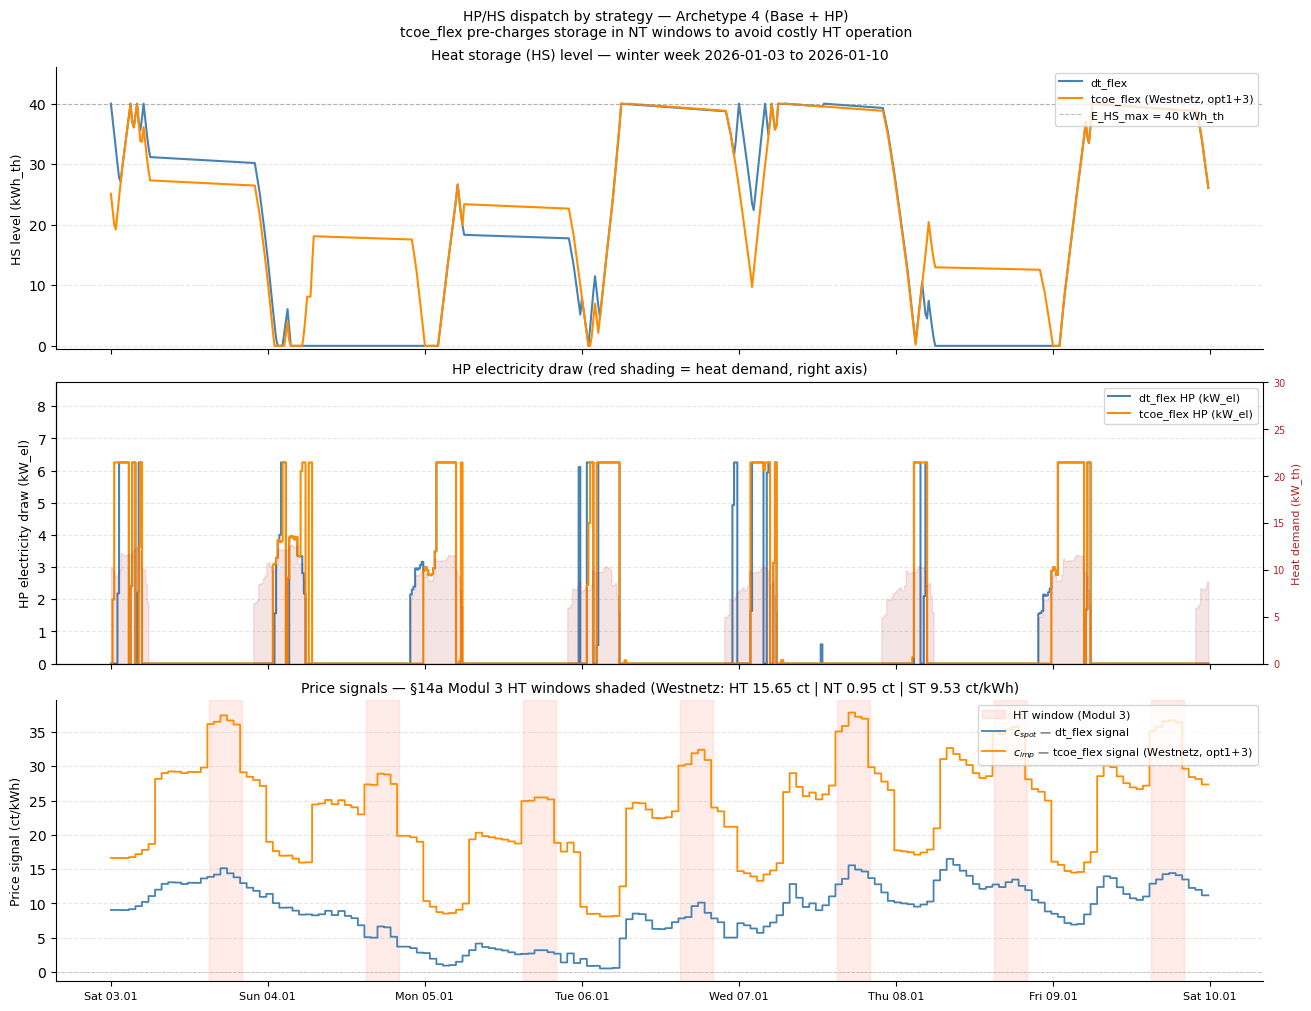

In [11]:
REF_DSO = 'Westnetz' if 'Westnetz' in schedules['tcoe_flex'] else next(iter(schedules['tcoe_flex']))
opt_tc  = schedules['tcoe_flex'][REF_DSO][3]
dbg_tc  = schedules['tcoe_flex'][REF_DSO][4]

Ehp_dt  = np.asarray(schedules['dt_flex'][2], dtype=float)
Ehp_tc  = np.asarray(schedules['tcoe_flex'][REF_DSO][2], dtype=float)

# HS state arrays (length T+1; drop last boundary to align with slot index)
Ehs_dt  = np.asarray(dbg_dt.get('E_HS_kWh_th', np.zeros(n+1)), dtype=float)[:-1]
Ehs_tc  = np.asarray(dbg_tc.get('E_HS_kWh_th', np.zeros(n+1)), dtype=float)[:-1]

# Reconstruct the price signal that tcoe_flex used
dso_ref = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
base_ap = float(dso_ref['Arbeitspreis_ct_kWh'])
mod2_ct = float(dso_ref['Module2_ct_kWh'])
hp_mod3 = build_hp_dso_rate_mod3(df['timestamp'], REF_DSO, dso_ref)

if opt_tc == 'opt1':
    c_imp_tc = spot_arr + base_ap + TAX_PRE_VAT
elif opt_tc == 'opt2':
    c_imp_tc = spot_arr + mod2_ct  + TAX_PRE_VAT
else:
    c_imp_tc = spot_arr + hp_mod3  + TAX_PRE_VAT

# HT mask for shading (slots where mod3 rate == HT rate)
HT_rate = float(dso_ref['HT_ct_kWh'])
ht_mask = (hp_mod3 == HT_rate)

# Winter week: first week in top-10% thermal-demand days
heat_daily = pd.Series(Q_heat_kWh, index=pd.to_datetime(df['timestamp'])).resample('D').sum()
win_start  = pd.Timestamp(heat_daily[heat_daily >= heat_daily.quantile(0.90)].index[0]).floor('D')
win_end    = win_start + pd.Timedelta(days=7)
mask       = ((df['timestamp'] >= win_start) & (df['timestamp'] < win_end)).values
x          = pd.to_datetime(df.loc[mask, 'timestamp'])

fig, (ax_hs, ax_hp, ax_pr) = plt.subplots(3, 1, figsize=(13, 10),
                                            constrained_layout=True, sharex=True)

# ── Panel 1: HS energy level ───────────────────────────────────────────────────
ax_hs.plot(x, Ehs_dt[mask], lw=1.5, color='steelblue',  label='dt_flex')
ax_hs.plot(x, Ehs_tc[mask], lw=1.5, color='darkorange', label=f'tcoe_flex ({REF_DSO}, {opt_tc})')
ax_hs.axhline(E_HS_max, color='grey', lw=0.8, ls='--', alpha=0.5, label=f'E_HS_max = {E_HS_max:.0f} kWh_th')
ax_hs.set_ylabel('HS level (kWh_th)', fontsize=9)
ax_hs.set_ylim(-0.5, E_HS_max * 1.15)
ax_hs.set_title(f'Heat storage (HS) level — winter week {win_start.date()} to {win_end.date()}', fontsize=10)
ax_hs.legend(loc='upper right', fontsize=8)
ax_hs.grid(axis='y', linestyle='--', alpha=0.3)
ax_hs.spines[['top', 'right']].set_visible(False)

# ── Panel 2: HP electricity draw + heat demand shading ────────────────────────
ax_hd = ax_hp.twinx()
ax_hd.fill_between(x, 0, Q_heat_kWh[mask] / 0.25,   # kWh_th/slot -> kW_th
                   alpha=0.12, color='firebrick', step='pre', label='heat demand (kW_th)')
ax_hd.set_ylabel('Heat demand (kW_th)', color='firebrick', fontsize=8)
ax_hd.tick_params(axis='y', labelcolor='firebrick', labelsize=7)
ax_hd.set_ylim(0, Q_HP_max_th * 1.5)

ax_hp.step(x, Ehp_dt[mask] * 4, where='pre', lw=1.5, color='steelblue',  label='dt_flex HP (kW_el)')
ax_hp.step(x, Ehp_tc[mask] * 4, where='pre', lw=1.5, color='darkorange', label=f'tcoe_flex HP (kW_el)')
ax_hp.set_ylabel('HP electricity draw (kW_el)', fontsize=9)
ax_hp.set_ylim(0, P_HP_max_el * 1.4)
ax_hp.set_title('HP electricity draw (red shading = heat demand, right axis)', fontsize=10)
ax_hp.legend(loc='upper right', fontsize=8)
ax_hp.grid(axis='y', linestyle='--', alpha=0.3)
ax_hp.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Price signals with HT band shading ───────────────────────────────
# Shade HT windows to make the Modul 3 structure visible
ht_in_win = ht_mask[mask]
changes   = np.diff(np.concatenate([[False], ht_in_win, [False]]).astype(int))
ht_starts = np.where(changes ==  1)[0]
ht_ends   = np.where(changes == -1)[0]
for s, e in zip(ht_starts, ht_ends):
    ax_pr.axvspan(x.iloc[s], x.iloc[min(e, len(x)-1)],
                  alpha=0.12, color='tomato',
                  label='HT window (Modul 3)' if s == ht_starts[0] else '')

ax_pr.step(x, spot_arr[mask],   where='pre', lw=1.3, color='steelblue',
           label='$c_{spot}$ — dt_flex signal')
ax_pr.step(x, c_imp_tc[mask],   where='pre', lw=1.3, color='darkorange',
           label=f'$c_{{imp}}$ — tcoe_flex signal ({REF_DSO}, {opt_tc})')
ax_pr.axhline(0, color='grey', lw=0.6, ls='--', alpha=0.4)
ax_pr.set_ylabel('Price signal (ct/kWh)', fontsize=9)
ax_pr.set_title(f'Price signals — §14a Modul 3 HT windows shaded '
                f'({REF_DSO}: HT {dso_ref["HT_ct_kWh"]} ct | NT {dso_ref["NT_ct_kWh"]} ct | ST {dso_ref["ST_ct_kWh"]} ct/kWh)',
                fontsize=10)
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(axis='y', linestyle='--', alpha=0.3)
ax_pr.spines[['top', 'right']].set_visible(False)
ax_pr.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))
ax_pr.xaxis.set_major_locator(mdates.DayLocator())
ax_pr.tick_params(axis='x', labelsize=8)

fig.suptitle('HP/HS dispatch by strategy — Archetype 4 (Base + HP)\n'
             'tcoe_flex pre-charges storage in NT windows to avoid costly HT operation',
             fontsize=10)
plt.show()


## Step 6 — Billing

**§14a billing options per strategy:**
- `no_flex` / `dt_flex`: billed under **opt1** (HP at base DSO rate + Module 1 annual rebate)
- `tcoe_flex`: billed under the **winning option** from the LP sweep per DSO

The Module 1 rebate (`Module1_rebate_EUR_year`) is an annual EUR credit (typically negative, i.e., a discount). It enters the DSO volumetric cost component and is included in the net subtotal before VAT.


In [ ]:
def bill_base_hp(E_base, E_hp, dso_row, opt):
    """Full annual bill (gross EUR) for a given schedule + §14a option.

    Billing components
    ------------------
    Spot energy    : spot_arr on (E_base + E_hp)
    DSO volumetric : option-dependent HP rate + Module 1 rebate for opt1 / opt1+3
    Levies         : TAX_PRE_VAT on (E_base + E_hp)
    Fixed          : DSO Grundpreis + SMART_OP_EUR
    VAT            : 19% on net subtotal
    """
    base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
    mod1_eur = float(dso_row['Module1_rebate_EUR_year'])   # typically < 0 (rebate)
    mod2_ct  = float(dso_row['Module2_ct_kWh'])

    cost_spot = np.sum((E_base + E_hp) * spot_arr) / 100.0

    if opt == 'opt1':
        cost_dso_vol = np.sum((E_base + E_hp) * base_ap) / 100.0 + mod1_eur
    elif opt == 'opt2':
        cost_dso_vol = (np.sum(E_base * base_ap) + np.sum(E_hp * mod2_ct)) / 100.0
    elif opt == 'opt1+3':
        hp_r = build_hp_dso_rate_mod3(df['timestamp'], str(dso_row['DSO']), dso_row)
        cost_dso_vol = np.sum(E_base * base_ap) / 100.0 + np.sum(E_hp * hp_r) / 100.0 + mod1_eur
    else:
        raise ValueError(f'Unknown §14a option: {opt}')

    cost_lev   = np.sum(E_base + E_hp) * TAX_PRE_VAT / 100.0
    cost_fixed = float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR

    subtotal = cost_spot + cost_dso_vol + cost_lev + cost_fixed
    return subtotal + VAT_RATE * subtotal


results = []
for _, dso_row in dso_tariffs.iterrows():
    dso_id = str(dso_row['DSO'])
    for strategy in ('no_flex', 'dt_flex', 'tcoe_flex'):
        if strategy == 'tcoe_flex':
            _val = schedules['tcoe_flex'][dso_id]
            E_g, E_hp = np.asarray(_val[0]), np.asarray(_val[2])
            opt = _val[3]
        else:
            E_g, _, E_hp = schedules[strategy]
            E_g, E_hp = np.asarray(E_g), np.asarray(E_hp)
            opt = 'opt1'

        base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
        mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
        mod2_ct  = float(dso_row['Module2_ct_kWh'])

        cost_spot = np.sum((q_base + E_hp) * spot_arr) / 100.0
        if opt == 'opt1':
            cost_dso_vol = np.sum((q_base + E_hp) * base_ap) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur
        elif opt == 'opt2':
            cost_dso_vol = (np.sum(q_base * base_ap) + np.sum(E_hp * mod2_ct)) / 100.0
            cost_mod1    = 0.0
        else:
            hp_r = build_hp_dso_rate_mod3(df['timestamp'], dso_id, dso_row)
            cost_dso_vol = np.sum(q_base * base_ap) / 100.0 + np.sum(E_hp * hp_r) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur

        cost_lev   = np.sum(q_base + E_hp) * TAX_PRE_VAT / 100.0
        cost_fixed = float(dso_row['Grundpreis_EUR_year'])
        subtotal   = cost_spot + cost_dso_vol + cost_lev + cost_fixed + SMART_OP_EUR
        vat        = VAT_RATE * subtotal

        results.append({
            'strategy'                     : strategy,
            'household_archetype'          : 4,
            'dso_id'                       : dso_id,
            'annual_energy_kwh'            : round(float(np.sum(q_base + E_hp)), 2),
            'cost_spot_net_eur'            : round(cost_spot,  2),
            'cost_dso_volumetric_net_eur'  : round(cost_dso_vol, 2),
            'cost_dso_fixed_net_eur'       : round(cost_fixed, 2),
            'cost_smart_operating_net_eur' : round(SMART_OP_EUR, 2),
            'cost_14a_mod1_net_eur'        : round(cost_mod1, 2),
            'cost_levies_pre_vat_eur'      : round(cost_lev,  2),
            'subtotal_net_eur'             : round(subtotal,  2),
            'vat_eur'                      : round(vat,       2),
            'total_tcoe_eur'               : round(subtotal + vat, 2),
            'billing_14a_option'           : opt,
            'optimized_14a_option'         : opt if strategy == 'tcoe_flex' else None,
        })

results = pd.DataFrame(results)
assert results['total_tcoe_eur'].notna().all(), 'NaN in total_tcoe_eur'
print(f'TCoE range (all 21 runs): {results["total_tcoe_eur"].min():.2f} – {results["total_tcoe_eur"].max():.2f} EUR/year')
print(f'Winning §14a options (tcoe_flex): {results[results["strategy"]=="tcoe_flex"]["billing_14a_option"].value_counts().to_dict()}')
results

TCoE range (all 21 runs): 2010.72 – 2745.35 EUR/year
Winning §14a options (tcoe_flex): {'opt1+3': 7}


,strategy,household_archetype,dso_id,annual_energy_kwh,cost_spot_net_eur,cost_dso_volumetric_net_eur,cost_dso_fixed_net_eur,cost_smart_operating_net_eur,cost_14a_mod1_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur,billing_14a_option,optimized_14a_option
0,no_flex,4,Westnetz,9000.00,810.12,719.00,80.30,100.0,-138.70,597.60,2307.02,438.33,2745.35,opt1,None
1,dt_flex,4,Westnetz,9096.96,674.60,728.24,80.30,100.0,-138.70,604.04,2187.18,415.56,2602.74,opt1,None
2,tcoe_flex,4,Westnetz,9080.96,716.67,372.19,80.30,100.0,-138.70,602.98,1872.14,355.71,2227.84,opt1+3,opt1+3
3,no_flex,4,Bayernwerk,9000.00,810.12,301.62,98.55,100.0,-123.18,597.60,1907.89,362.50,2270.39,opt1,None
4,dt_flex,4,Bayernwerk,9096.96,674.60,306.20,98.55,100.0,-123.18,604.04,1783.38,338.84,2122.23,opt1,None
5,tcoe_flex,4,Bayernwerk,9081.35,675.53,268.54,98.55,100.0,-123.18,603.00,1745.62,331.67,2077.29,opt1+3,opt1+3
6,no_flex,4,E.DIS,9000.00,810.12,384.05,76.65,100.0,-108.25,597.60,1968.42,374.00,2342.42,opt1,None
7,dt_flex,4,E.DIS,9096.96,674.60,389.35,76.65,100.0,-108.25,604.04,1844.64,350.48,2195.12,opt1,None
8,tcoe_flex,4,E.DIS,9079.99,686.63,223.48,76.65,100.0,-108.25,602.91,1689.68,321.04,2010.72,opt1+3,opt1+3
9,no_flex,4,Netze BW,9000.00,810.12,500.52,84.00,100.0,-180.78,597.60,2092.24,397.53,2489.76,opt1,None


## Step 7 — Summary and export

In [15]:
# ── Table 1: no_flex cost breakdown (reference — comparable to Archetypes 1–3) ────
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id', 'cost_spot_net_eur', 'cost_dso_volumetric_net_eur',
        'cost_14a_mod1_net_eur', 'cost_dso_fixed_net_eur',
        'cost_smart_operating_net_eur', 'cost_levies_pre_vat_eur',
        'vat_eur', 'total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'               : 'Spot net (€)',
          'cost_dso_volumetric_net_eur'     : 'DSO vol (€)',
          'cost_14a_mod1_net_eur'           : '§14a Mod1 rebate (€)',
          'cost_dso_fixed_net_eur'          : 'DSO fix (€)',
          'cost_smart_operating_net_eur'    : 'Smart op. (€)',
          'cost_levies_pre_vat_eur'         : 'Levies pre-VAT (€)',
          'vat_eur'                         : 'VAT (€)',
          'total_tcoe_eur'                  : 'TCoE no_flex (€/yr)',
      }))

print(f'Annual grid draw (no_flex): {E_grid_nf.sum():.2f} kWh  '
      f'(base {q_base.sum():.1f} kWh  |  HP {E_hp_profile.sum():.1f} kWh)')
print('\nTable 1 — no_flex cost breakdown (reference, §14a opt1):')
display(nf)

# ── Table 2: strategy comparison + flex savings ────────────────────────────────
piv = results.pivot_table(index='dso_id', columns='strategy',
                           values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex', 'dt_flex', 'tcoe_flex']]
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={
    'no_flex'   : 'TCoE no_flex (€/yr)',
    'dt_flex'   : 'TCoE dt_flex (€/yr)',
    'tcoe_flex' : 'TCoE tcoe_flex (€/yr)',
})
print('\nTable 2 — strategy comparison and flex savings vs no_flex:')
display(piv)

out = OUTPUTS / 'results_base_hp_2026.csv'
results.to_csv(out, index=False)
print(f'\nSaved : {out}')
print(f'Rows  : {len(results)}  (3 strategies x 7 DSOs)')


Annual grid draw (no_flex): 9000.00 kWh  (base 4500.0 kWh  |  HP 4500.0 kWh)

Table 1 — no_flex cost breakdown (reference, §14a opt1):


,Spot net (€),DSO vol (€),§14a Mod1 rebate (€),DSO fix (€),Smart op. (€),Levies pre-VAT (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,,
Westnetz,810.12,719.00,-138.70,80.30,100.0,597.6,438.33,2745.35
Bayernwerk,810.12,301.62,-123.18,98.55,100.0,597.6,362.50,2270.39
E.DIS,810.12,384.05,-108.25,76.65,100.0,597.6,374.00,2342.42
Netze BW,810.12,500.52,-180.78,84.00,100.0,597.6,397.53,2489.76
Stromnetz Berlin,810.12,548.22,-123.18,33.36,100.0,597.6,396.97,2486.26
SH Netz,810.12,460.77,-115.23,94.90,100.0,597.6,392.04,2455.43
MITNETZ STROM,810.12,453.35,-114.55,73.00,100.0,597.6,386.47,2420.54



Table 2 — strategy comparison and flex savings vs no_flex:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,2270.39,2122.23,2077.29,148.16,193.10
E.DIS,2342.42,2195.12,2010.72,147.30,331.70
MITNETZ STROM,2420.54,2274.21,2079.43,146.33,341.11
Netze BW,2489.76,2344.89,2224.09,144.87,265.67
SH Netz,2455.43,2309.21,2070.11,146.22,385.32
Stromnetz Berlin,2486.26,2341.27,2136.20,144.99,350.06
Westnetz,2745.35,2602.74,2227.84,142.61,517.51



Saved : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_hp_2026.csv
Rows  : 21  (3 strategies x 7 DSOs)
